# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [54]:
STUDENT_NAME = "Ngô Hoàng Long"  # TODO: Họ và tên
STUDENT_ID = "2411918"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Ngô Hoàng Long (2411918)


In [55]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
import shutil
drive.mount("/content/drive")

DRIVE_DIR_PATH = Path("/content/drive/MyDrive/pyml/data")
DRIVE_DATA_PATH = DRIVE_DIR_PATH / "automobile_raw.csv"

COLAB_DIR_PATH = Path("/content/data/raw")
COLAB_DIR_PATH.mkdir(parents=True, exist_ok=True)
COLAB_DATA_PATH = COLAB_DIR_PATH / "automobile_raw.csv"

if DRIVE_DIR_PATH.exists():
  shutil.copy2(DRIVE_DATA_PATH, COLAB_DATA_PATH)
  print("Copied automobile_raw to:", COLAB_DATA_PATH)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
    (COLAB_DATA_PATH if COLAB_DATA_PATH.exists() else None),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied automobile_raw to: /content/data/raw/automobile_raw.csv
Data path: /content/data/raw/automobile_raw.csv


In [56]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

In [89]:
raw_df.head()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    object 
 16  engine_size        205 non

## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [57]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)
display(logits.shape) # 4 điểm dữ liệu, mỗi điểm có 3 class là 0, 1, 2

(4, 3)

In [58]:
# TODO N1
row_maxes = np.max(logits, axis=1, keepdims=True) # tìm max của mỗi hàng
shifted_logits = logits - row_maxes
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)  # class có softmax
                                                            # xác suất cao nhất
                                                            # của từng data point
confidence_scores = np.max(class_probabilities, axis=1) # mức độ tự tin của model
                                                        # đối với label mà nó dự
                                                        # đoán (tương ứng với softmax
                                                        # cao nhất)

In [59]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [60]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [61]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [62]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [63]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

Sau khi inference, ta sẽ có thông tin tại mỗi data point như sau:
- `predicted_classes[i]`: Model dự đoán class nào (tương ứng với xác suất (softmax) cao nhất.
- `true_labels[i]`: Ground-truth tương ứng với data point đó (nhãn thật).
- `confidence_scores[i]`: Mức độ tự tin/chắc chắn của model về dự đoán của nó tương ứng với `predicted_classes[i]`.

Ta cần phải tạo review queue tại 1 trong 2 trường hợp sau:
- Prediction của model sai (tức `predicted_classes[i] != true_labels[i]`).
- Confidence cho dự đoán `predicted_classes[i]` bé hơn `0.70`.

In [64]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores > confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [65]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [66]:
# TODO N4
normalized_batch = image_batch_uint8.astype(dtype=np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [82]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH, keep_default_na=False, low_memory=False)
raw_shape = raw_df.shape
raw_missing_marker_count = int((raw_df == "?").sum().sum()) # Tổng NA trên toàn bộ frame

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [68]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [85]:
# TODO D2
df_clean = raw_df.replace("?", np.nan).copy()
for column in NUMERIC_COLUMNS:
  df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce") #return a new series
missing_by_column = df_clean.isna().sum().sort_values(ascending=False)

In [87]:
# Thống kê missing value cho các biến numeric
numeric_missing = df_clean[NUMERIC_COLUMNS].isna().sum()
numeric_missing_pct = (numeric_missing / len(df_clean)) * 100

# Tạo DataFrame báo cáo
missing_report = pd.DataFrame({
    'Missing Values': numeric_missing,
    'Percentage (%)': numeric_missing_pct.round(2)
}).sort_values(by='Missing Values', ascending=False)

display(missing_report)

,Missing Values,Percentage (%)
normalized_losses,41,20.00
price,4,1.95
stroke,4,1.95
bore,4,1.95
horsepower,2,0.98
peak_rpm,2,0.98
wheel_base,0,0.00
symboling,0,0.00
engine_size,0,0.00
curb_weight,0,0.00


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

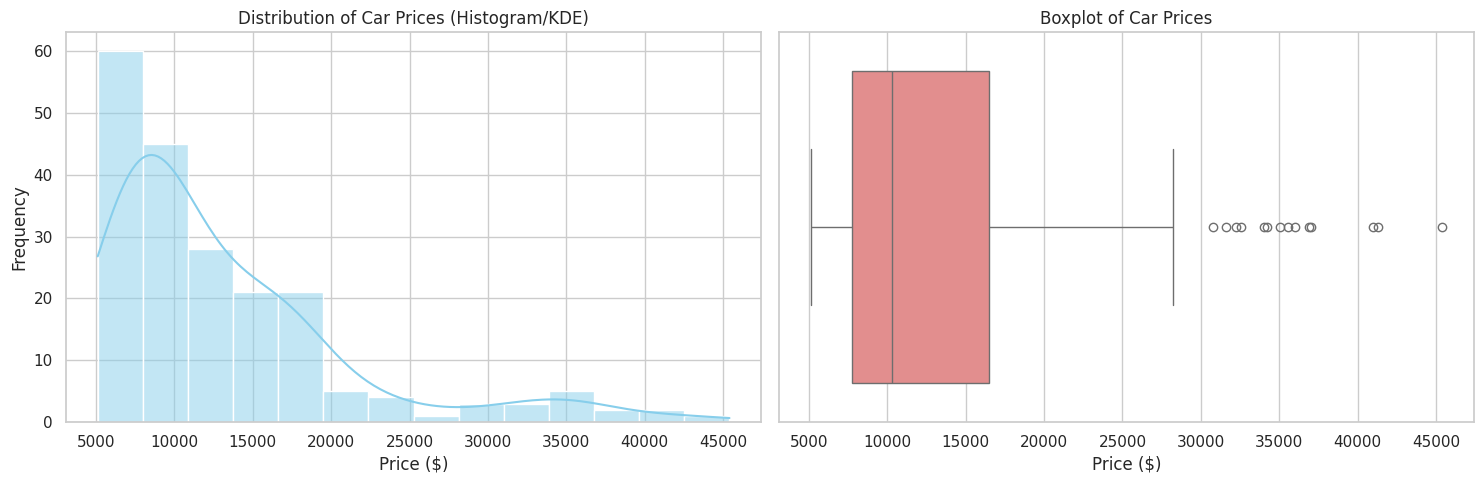

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram và KDE
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Car Prices (Histogram/KDE)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=df_clean['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of Car Prices')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

**Nhận xét**
- Ta không nên fill, nếu không muốn nói là không được, fill tất cả numeric columns bằng một giá trị ngẫu nhiên nào đó vì:
  - Thứ nhất, mỗi cột numeric đều đại diện cho một đặc tính của quần thể mà ta đang quan tâm. Nếu đơn thuần chỉ điền ngẫu nhiên một giá trị bất kỳ vào các phần bị khuyết, thì các điểm đó có thể đại diện cho một thực thể "vô lý" nào đó không có thực ngoài đời (ví dụ như `length = -1`). Lúc này, khi xử lý outlier thì những điểm được điền vào trên cũng sẽ trở thành các điểm dị biệt so với phần đông các điểm khác và sẽ bị loại bỏ.
  - Thứ hai, xét `n` điểm dữ liệu của dataset, có `m` điểm bị khuyết, giả sử như ta điền vào một số `c` bất kỳ, khi đấy kỳ vọng mới của biến numeric đấy sẽ bị kéo lệch về phía `c`, tạo ra bias estimation lớn. Trọng đại hơn, hành động này còn làm thay đổi hoàn toàn cấu trúc phương sai của biến đó. Việc chèn vào một lượng lớn các giá trị giống hệt nhau sẽ làm giảm phương sai tự nhiên xung quanh điểm đó, hoặc ngược lại, làm tăng đột biến phương sai tổng thể nếu `c` là một giá trị cực đoan. Hệ số tương quan Pearson giữa biến bị điền vào và các biến độc lập khác cũng sẽ bị suy giảm mạnh (attenuation) do sự xuất hiện của các hằng số không mang theo bất kỳ thông tin hiệp phương sai nào.

- Với biến `price`, vì tỷ lệ missing của nó rất ít (chỉ có `1.95%`), ta có thể drop trực tiếp các hàng chứa missing mà không gây ảnh hưởng đáng kể đến phân phối gốc của biến.
- Việc cột `normalized_losses` có tỷ lệ thiếu lên tới `20%` có thể sẽ làm cho:
  - Univariate analysis đối với biến này sẽ trở nên thiếu tin cậy hơn.
  - Tương quan giữa biến này với target là `price` hoặc các biến khác có thể sẽ bị bias.
  - Hiệu suất của mô hình dự đoán giảm nếu xử lý sai cách (như drop toàn bộ các dòng bị missing, hoặc impute sai giá trị).

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [70]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [90]:
# TODO D3

analysis_df = df_clean[AUTO_FEATURES].dropna().copy()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [91]:
# TODO D4
price_index = AUTO_FEATURES.index("price")
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask].copy()

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [92]:
# TODO D5

engine_size = analysis_df["engine_size"].to_numpy(dtype=np.float64)
price = analysis_df["price"].to_numpy(dtype=np.float64)

engine_price_corr = np.corrcoef(engine_size, price)[0, 1]

price_by_body_style = (
    df_clean
    .groupby("body_style")["price"]
    .mean()
    .sort_index()
)

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

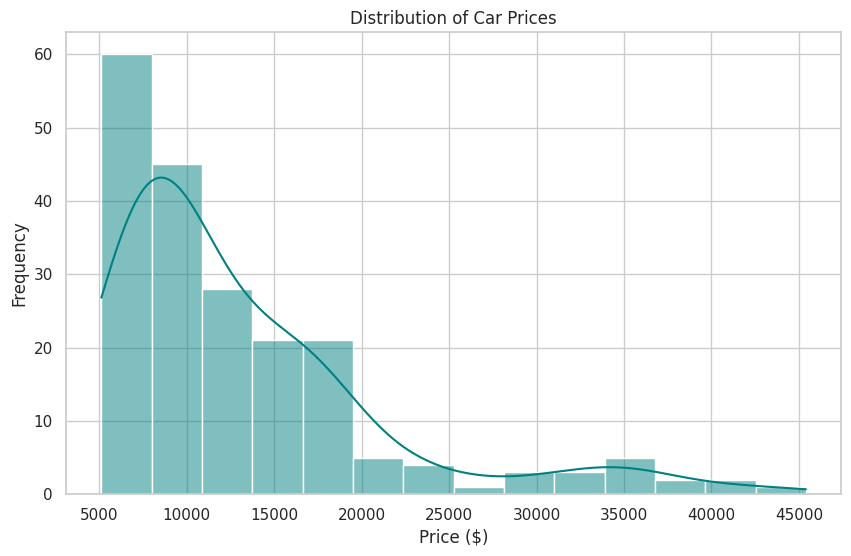

In [93]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], kde=True, color='teal')
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

**Nhận xét:**

Dựa vào histogram của `price`, ta có thể thấy phân phối của biến này lệch phải khá nặng, tập trung nhiều ở phân khúc từ `5000 - 15000$`. Ngoài ra, phần đuôi của phân phối trải dài từ phân khúc `20000 - 45000` với mật độ tập trung của thấp hơn đáng kể so với phân khúc giá rẻ, cho thấy biến này có thể có nhiều outlier.

## M2.2 Dataset có cân bằng theo body style không?

/tmp/ipykernel_1345/1479918042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')


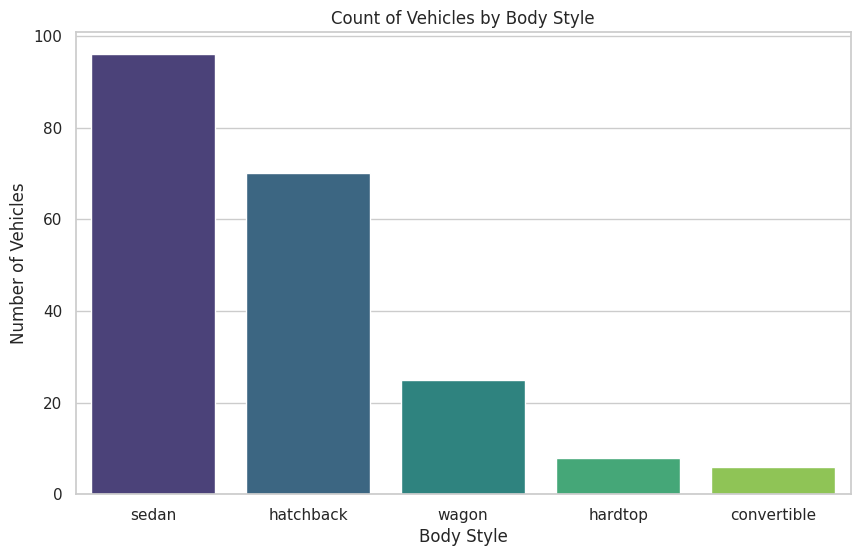

In [94]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')
plt.title('Count of Vehicles by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Number of Vehicles')
plt.show()

**Nhận xét:** Dựa vào countplot trên, ta có thể thấy dữ liệu bị mất cân bằng lớp rõ rệt khi dòng xe `sedan` và `hatchback` chiếm đại đa số lượng xe trong dataset. Các dòng như `convertible` hay `hardtop` có số lượng mẫu rất hạn chế.

## M2.3 Price khác nhau theo body style ra sao?

/tmp/ipykernel_1345/1123184408.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


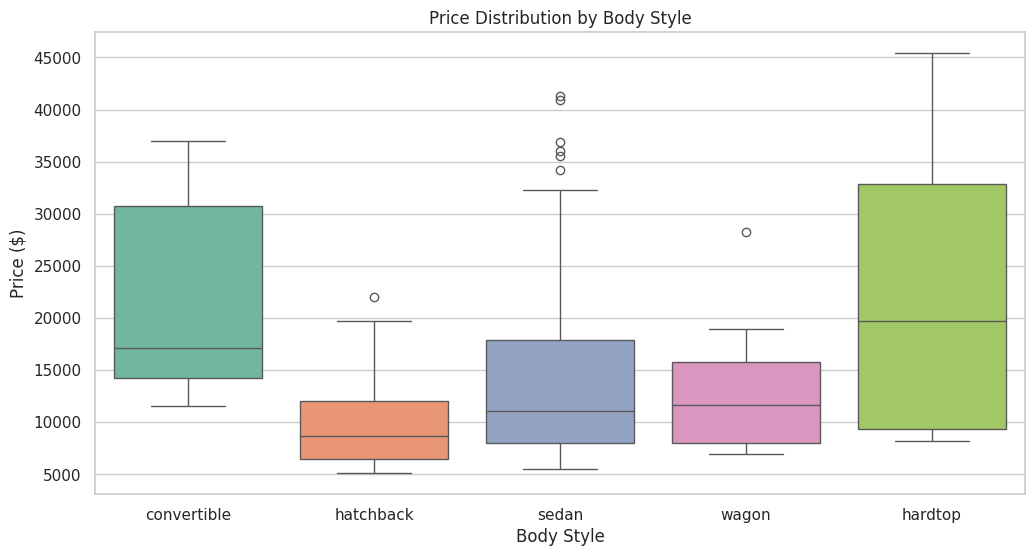

In [95]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')
plt.title('Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.show()

**Nhận xét:** Hardtop và Convertible có dải giá rộng và trung vị ở mức cao nhất, từ tầm trung đổ lên, cho thấy hai kiểu xe này thuộc phân khúc từ tầm trung đến cao cấp. Ngược lại, ba kiểu xe Hatchback, Sedan, Wagon lại có dải giá hẹp, và trung vị chỉ ở mức thấp, thể hiện rằng chúng thuộc phân khúc xe giá rẻ. Ngoài ra, ta có thể thấy giữa hai phân khúc xe này (Convertible-Hardtop và Hatchback-Sedan-Wagon) có mức độ overlap không quá đáng kể. Từ những nhận xét trên ta có thể nhận định rằng biến `body_style` là một predictor quan trọng, mang lại nhiều thông tin dự đoán cho mô hình theo từng kiểu xe.

## M2.4 Engine size liên quan thế nào tới price?

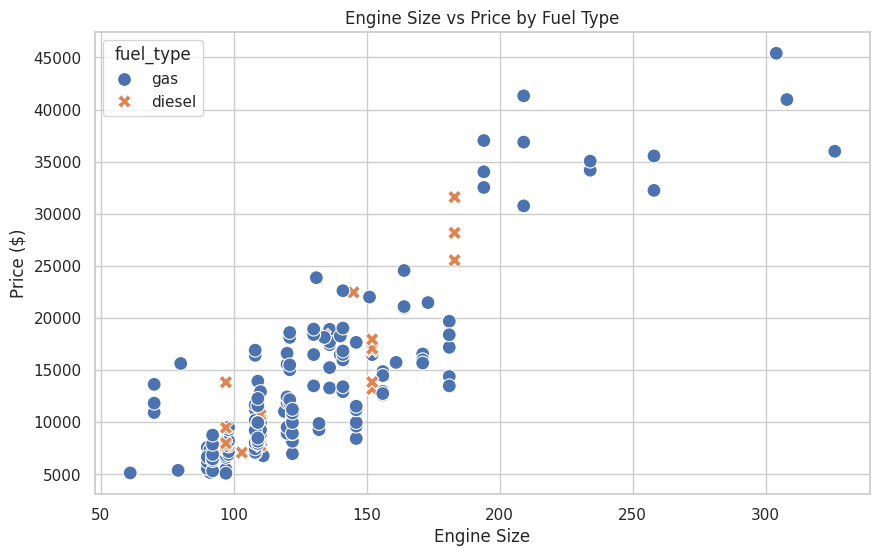

In [96]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', style='fuel_type', s=100)
plt.title('Engine Size vs Price by Fuel Type')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.show()

**Nhận xét:** Có một mối quan hệ tuyến tính khá rõ ràng giữa kích thước động cơ và giá xe. Xe chạy xăng (gas) xuất hiện ở mọi phân khúc, trong khi xe diesel tập trung ở nhóm động cơ cỡ trung.

## M2.5 Các feature numeric tương quan ra sao?

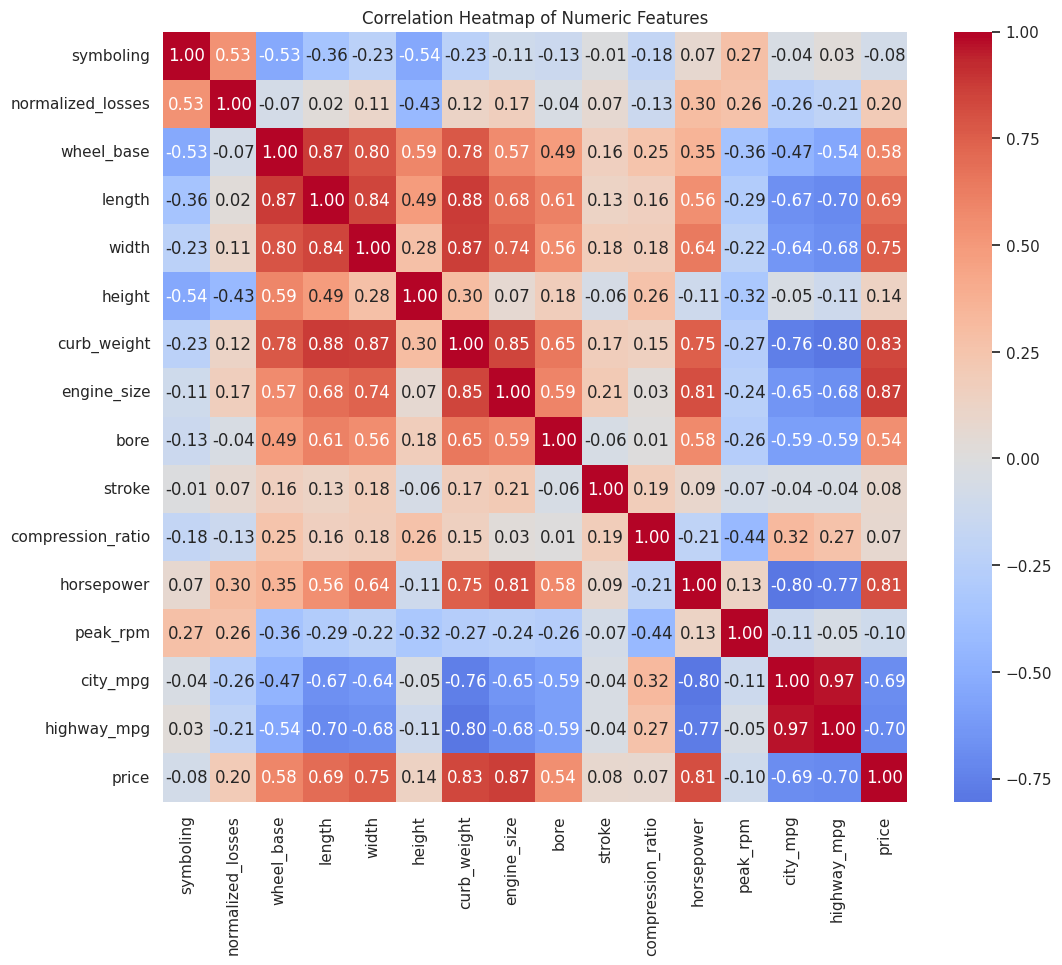

In [97]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Nhận xét:** `price` tương quan rất mạnh với `curb_weight`, `engine_size` và `horsepower` (đều > 0.8). Ngược lại, giá xe tương quan nghịch với `city_mpg` và `highway_mpg`, nghĩa là xe đắt tiền (thường mạnh hơn, nặng hơn) sẽ tiêu tốn nhiều nhiên liệu hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

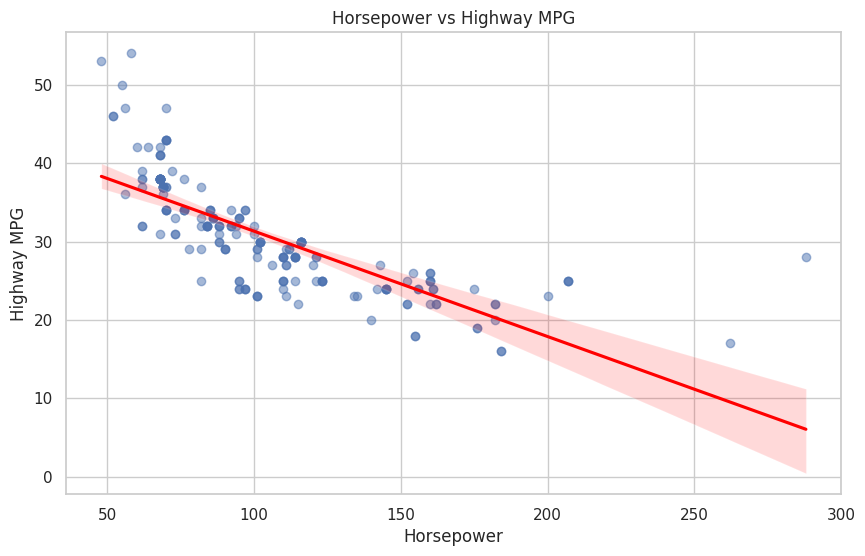

In [98]:
# TODO M2.6: biểu đồ tự chọn
# Câu hỏi: Mã lực (horsepower) cao có ảnh hưởng tiêu cực đến hiệu suất nhiên liệu (highway_mpg) không?
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='horsepower', y='highway_mpg', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Horsepower vs Highway MPG')
plt.xlabel('Horsepower')
plt.ylabel('Highway MPG')
plt.show()

**Nhận xét:** Biểu đồ cho thấy sự đánh đổi rõ rệt mà ai cũng biết trong thực tế: khi mã lực tăng lên, hiệu suất tiêu thụ nhiên liệu đường trường (`highway_mpg`) sẽ giảm xuống đáng kể, tức xe sẽ càng tốn xăng hơn nếu đi đường dài. Đường hồi quy màu đỏ thể hiện xu hướng giảm tuyến tính rất rõ ràng.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

**3-5 phát hiện chính:**
1. **Tương quan mạnh giữa kích thước và giá xe:** Các biến như `curb_weight` (0.84) và `engine_size` (`0.87`) có tương quan thuận rất mạnh với `price`, cho thấy kích thước xe là yếu tố quan trọng cung cấp thông tin dự đoán giá xe.
2. **Hiệu suất nhiên liệu thấp ở xe đắt tiền:** Có sự tương quan nghịch rõ rệt giữa `price` và `highway_mpg` (`-0.70`), phản ánh việc các dòng xe sang trọng thường ưu tiên hiệu suất động cơ hơn là hiệu quả tiết kiệm xăng.
3. **Phân khúc Body Style:** Xe `convertible` và `hardtop` luôn nằm ở nhóm giá cao nhất, trong khi `hatchback` là phân khúc bình dân nhất.
4. **Phân phối giá lệch:** Thị trường ô tô trong dataset này tập trung chủ yếu vào phân khúc giá rẻ và tầm trung (dưới `15,000$`).

**Hạn chế của dataset:**
- Dữ liệu thiếu (missing values) ở cột `normalized_losses` lên tới 20%, gây khó khăn cho việc phân tích rủi ro bảo hiểm.
- Kích thước mẫu nhỏ (205 dòng) và mất cân bằng giữa các loại `body_style`, làm giảm khả năng tổng quát hóa của mô hình cho các nhóm thiểu số như `hardtop`.

**Tương quan không đồng nghĩa nhân quả:**
- Ví dụ: `wheel_base` (chiều dài cơ sở) tương quan thuận với `price`. Tuy nhiên, việc kéo dài trục bánh xe không trực tiếp dẫn đến việc xe sẽ đắt hơn, mà có thể chỉ là vì các dòng xe sang thường được thiết kế lớn hơn để tạo sự thoải mái, vô tình dẫn đến sự tương quan thuận chiều, nhưng không hề có mối quan hệ nhân quả trực tiếp.

**Câu hỏi phân tích tiếp:**
- Liệu hệ thống nhiên liệu (`fuel_system`) kết hợp với `aspiration` (turbo vs std) có ảnh hưởng đáng kể đến mô-men xoắn và khả năng tăng tốc của xe hay không?